In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Part (1): Determining y(x) using shooting method

In [13]:
def f1(x, y):                #Defining the function
    E = 2e+11
    I = 3e-4
    W = 15e+3
    L = 3
    #return np.array([y[1], W*x/(2*E*I)*(L-x)])
    return np.array([y[1], W*L/(2*E*I)*x - W/(2*E*I)*x*x])

In [10]:
def rk4(f, h, x, y):          #Writing out the RK4
    k1 = h*f(x, y)
    k2 = h*f(x, y+k1/2)
    k3 = h*f(x, y+k2/2)
    k4 = h*f(x, y+k3)
    
    return y + (k1+2*k2+2*k3+k4)/6

In [11]:
def eval_rk4(f, ti, tf, h, yi):             #Calling the RK4
    a = np.arange(ti, tf+h, h) 
    y_corr = np.zeros((len(a), 2))
    y_corr[0] = yi
    for i in range(len(a[1:])):
        y_corr[i+1] = rk4(f, h, a[i], y_corr[i])
    return y_corr

We are given the values of $y(0)$ and $y(L)$ to be 0. Now, the entire solution can be obtained if we can figure out the value of $y'(0)$. We can take trial solutions for $y'(0)$ and then thus convert this BVP to IVP. Then, we can see for which value of $y'(0)$ we get the value at the boundary to be zero, that is, $y(L)=0$. 

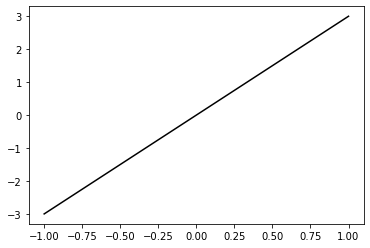

In [21]:
ydasharr = np.arange(-1,1.001,0.001)            #Making an array of all possible y'(0)s
pos_at_end_arr = np.zeros(len(ydasharr))
for i in range(len(ydasharr)):
    pos_at_end = eval_rk4(f1, 0.0, 3.0, 0.001, np.array([0, ydasharr[i]]))[-1][0]
    pos_at_end_arr[i] = pos_at_end
plt.plot(ydasharr, pos_at_end_arr, color='k')   #Plotting to see y(L) for all possible values of y'(0)s.

In [18]:
#eval_rk4(f1, 0.0, 3.0, 0.001, np.array([0, 0]))[-1][0]

0.0008434686562812518

In [22]:
def functional_pos_at_end_arr(x):     #Getting the above plot in functional form so we can use bisection to find the root
    return eval_rk4(f1, 0.0, 3.0, 0.001, np.array([0, x]))[-1][0]
    

In [23]:
L = 0                                                         #Code for bisection method
R = 2
tol = 0.000001
maxiter=100
def bisection(f, L, R,tol):
    print("Iteration\t\tL\t\tR\t\tC")
    print("---------------------------------------------------------------------------------------------")
    if f(L)*f(R)>0:
        print("Bad interval! ")

    elif f(L)*f(R)==0:
        if f1(L) == 0:
            print("The root is " + str(L))
        else:
            print("The root is " + str(R))
    elif f(L)*f(R)<0:
        C = (L+R)/2
        iteration = 1
        
        while abs(f(C))>tol and iteration<=maxiter:
            if f(L)*f(C)<0:
                R = C
            else:
                L = C
            C = (L+R)/2
            print(f"{iteration:0d}\t\t{L:.8f}\t{R:.8f}\t{C:.8f}")
            iteration += 1
            if iteration > maxiter:
                print("Couldn't converge in 100 steps!")
                break

In [33]:
bisection(functional_pos_at_end_arr, -1, 1, 0.00000001)      #Using bisection to find the value of y'(0)

Iteration		L		R		C
---------------------------------------------------------------------------------------------
1		-1.00000000	0.00000000	-0.50000000
2		-0.50000000	0.00000000	-0.25000000
3		-0.25000000	0.00000000	-0.12500000
4		-0.12500000	0.00000000	-0.06250000
5		-0.06250000	0.00000000	-0.03125000
6		-0.03125000	0.00000000	-0.01562500
7		-0.01562500	0.00000000	-0.00781250
8		-0.00781250	0.00000000	-0.00390625
9		-0.00390625	0.00000000	-0.00195312
10		-0.00195312	0.00000000	-0.00097656
11		-0.00097656	0.00000000	-0.00048828
12		-0.00048828	0.00000000	-0.00024414
13		-0.00048828	-0.00024414	-0.00036621
14		-0.00036621	-0.00024414	-0.00030518
15		-0.00030518	-0.00024414	-0.00027466
16		-0.00030518	-0.00027466	-0.00028992
17		-0.00028992	-0.00027466	-0.00028229
18		-0.00028229	-0.00027466	-0.00027847
19		-0.00028229	-0.00027847	-0.00028038
20		-0.00028229	-0.00028038	-0.00028133
21		-0.00028133	-0.00028038	-0.00028086
22		-0.00028133	-0.00028086	-0.00028110
23		-0.00028133	-0.00028110	

So, using the shooting method, we get $y'(0) = -0.00028116$. We now use this, and thereby convert this question to an IVP Problem, with $y(0) = 0$, and $y'(0) = -0.00028116$. 

In [37]:
finalsol = eval_rk4(f1, 0.0, 3.0, 0.001, np.array([0, -0.00028116]))     #Correct solution

In [39]:
functional_y = finalsol.T[0]

## Answer to part (1)

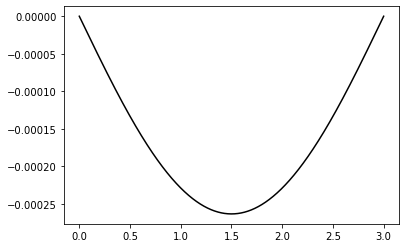

In [40]:
a1 = np.arange(0.0,3.001,0.001)            #The plot of the actual solution
plt.plot(a1, functional_y, color='k')

## Part (2): Finding the maximum value of L for which the beam has no deflection


In [62]:
L2 = np.arange(0.00000001, 5.010001, 0.01)     #Making an array of some possible Ls

We define a measure of deflection (called score) as follows:

For a given solution for a given value of L, we take the sum of squares of all points. This gives a metric of its distance from the line y=0. Thus, for whichever L this metric gives the minimum result (ideally zero), it will be that value of L that we are looking for. 

In [68]:
scorearray = np.zeros(len(L2))           #Empty array of scores
for r in range(len(L2)):
    temp = eval_rk4(f1, 0.0, L2[r], 0.001, np.array([0, -0.00028116]))
    ysoltemp = temp.T[0]
    score_for_shape = np.sum(ysoltemp**2)
    ##score_for_shape = np.sum((eval_rk4(f1, 0.0, L2[r], 0.001, np.array[0, -0.00028116]).T[0])**2)
    scorearray[r] = score_for_shape     #Appending the score to the array 

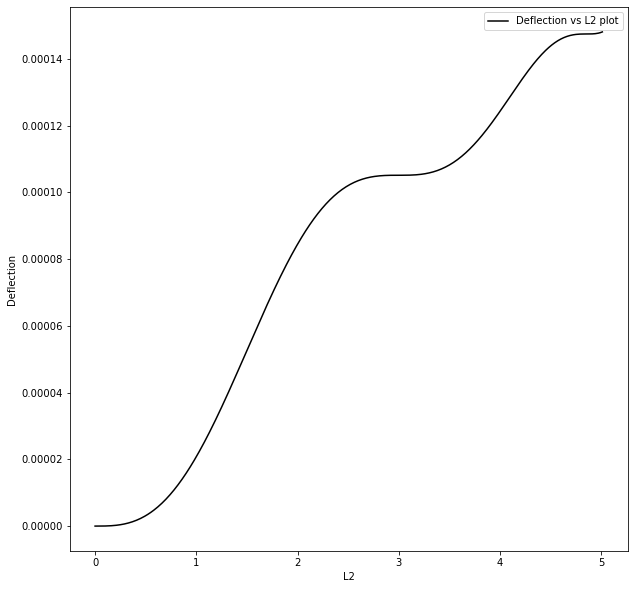

In [69]:
plt.figure(figsize=(10,10))      #Making the plot
plt.plot(L2, scorearray, color='k', label='Deflection vs L2 plot')
plt.xlabel('L2')
plt.ylabel('Deflection')
plt.legend()
plt.show()           #Showing the plot

As can be seen from the plot, the beam will have zero deflection (or atleast minimum) only at L=0. After that, for a small range of values, we get small deflection. However, since the question asks for $\textbf{maximum value of L where the beam will have no deflection}$, we answer that this value of L is $L=0$.